# Unit 02: Computing with Data in Python

# Outline of ECE 3

The course ECE 3 is organized into 4 units.

- Unit 01: Welcome to Python
- **Unit 02: Computing with Data in Python**
- Unit 03: Summarizing Data in Python
- Unit 04: Predicting from Data with Machine Learning in Python

# Outline of Unit 02

- **02: Computing with Data in Python**
  - Vector
      - Vectors: assigning, accessing, visualizing
      - Vector addition, subtraction, scaling
      - **Inner product, norm, triangle inequality, distances, angles, Cauchy-Schwarz inequality**
  - Matrix
      - **Matrices, special matrices**
      - Matrix transpose, addition, subtraction, scaling
      - Matrix-vector multiplication, Matrix-matrix multiplication

# Outline of Unit 02

- **02: Computing with Data in Python**
  - Vector
      - Vectors: assigning, accessing, visualizing
      - Vector addition, subtraction, scaling
      - Inner product, norm, triangle inequality, distances, angles, Cauchy-Schwarz inequality
  - Matrix
      - Matrices, special matrices
      - **Matrix-vector multiplication, Matrix-matrix multiplication**
      - **Matrix transpose, addition, subtraction, scaling**

## Recap: Definition of a Matrix

$\color{#EF5645}{\text{Definition}}$: A _matrix_ is a rectangular array of numbers, e.g.:
$$A =\begin{vmatrix}
0   & 1  & -2.3  \\
1.3 & 4  & -0.1 
\end{vmatrix}$$

- Its _shape_ is: (number of rows) x (number of columns).
- Its elements are called: _entries_
- $A_{i, j}$ refers to element at ith row and jth column.
  - i is the _row index_ and j is the _column index_.
  
$\color{#EF5645}{\text{Remark:}}$ We often denote a matrix with a capital letter such as A and vectors with a lower case letter such as a.

In [1]:
import numpy as np

A = np.array([
    [0, 1, -2.3], 
    [1.3, 4, -0.1]
])

In [2]:
print(A)

[[ 0.   1.  -2.3]
 [ 1.3  4.  -0.1]]


In [3]:
print(A.shape)

(2, 3)


# Matrix-Vector Operations

## Matrix-Vector Multiplication

$\color{#EF5645}{\text{Definition}}$: If $A$ is an $n \times m$ matrix and $x$ is an $m$-vector, then the _matrix-vector_ product $y = Ax$ is the $n$-vector with elements: 
$$y_i = \sum_{j = 1}^m A_{ij}x_j$$

$\color{#047C91}{\text{Example}}$: 

$$\begin{vmatrix}
0 & 2 & -1 \\
-2 & 1 & 1
\end{vmatrix} 
\begin{vmatrix}
2 \\
1 \\
-1
\end{vmatrix} = 
\begin{vmatrix}
3 \\
-4
\end{vmatrix}$$

In [63]:
A = np.array([
    [0, 2, -1],
    [-2, 1, 1]])
x = np.array([2, 1, -1])

y = A @ x
y = A.dot(x)

print(y)

[ 3 -4]


$\color{#047C91}{\text{Exercise}}$: Can you write a function that computes the matrix-vector product only using dot products?

In [67]:
def matrix_vector_dot(A, x):
    n, m = np.shape(A) # n rows, m columns
    y = np.zeros(n) # n-vector
    for i in range(n):
        a = A[i,:]
        y[i] = np.dot(a, x)
    return y

In [68]:
A = np.array([
    [0, 2, -1],
    [-2, 1, 1]])
x = np.array([2, 1, -1])
y = matrix_vector_dot(A, x)
print(y)

[ 3. -4.]


$\color{#047C91}{\text{Exercise}}$: Can you write a function that computes the matrix-vector product only using linear combinations?

In [ ]:
def matrix_vector_linear_comb(A, x):
    n, m = np.shape(A)
    y = np.zeros(n)
    for j in range(m):
        a = A[:,j]
        y += x[j] * a
    return y

In [64]:
A = np.array([
    [0, 2, -1],
    [-2, 1, 1]])
x = np.array([2, 1, -1])
y = matrix_vector_linear_comb(A, x)
print(y)

[ 3. -4.]


$\color{#047C91}{\text{Exercise}}$: If $a$ and $b$ are $n$-vectors, what is the matrix vector product $a^Tb$?

In [65]:
a = np.array([[2, 1, -1, 4, 5, -9]]).T # (6 x 1) column vector
b = np.array([[-1, 1, 4, 4, -1, 8]]).T # (6 x 1) column vector
y = a.T @ b # (1 x 6) row vector/matrix times (6 x 1) column vector
print(y)

[[-66]]


### Matrices are Transformations of Vectors

A matrix can be thought of as a *transformation* that acts on vectors.  
For example, the 2×2 90° rotation matrix $R_{90}$,


$$R_{90} = 
\begin{vmatrix}
0 & -1\\
1 & 0
\end{vmatrix}
$$

rotates any 2D vector by 90°.  

Let's apply $R_{90}$ to the vector $v = (1,1)$ and visualize the result.

In [33]:
# Define the 90° rotation matrix and the vector v
R = np.array([[0, -1],
              [1,  0]])
v = np.array([1, 1])
Rv = R @ v

In [34]:
print(f"shape of R: {R.shape}")
print(f"shape of v: {v.shape}")
print(f"shape of Rv:{Rv.shape}")

shape of R: (2, 2)
shape of v: (2,)
shape of Rv:(2,)


In [39]:
print(Rv)

[-1  1]


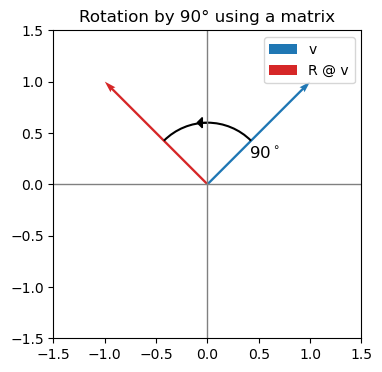

In [46]:
import matplotlib.pyplot as plt
from matplotlib.patches import Arc

plt.figure(figsize=(4,4)) # plot setup
plt.axhline(0, color='gray', lw=1)
plt.axvline(0, color='gray', lw=1)
plt.quiver(0, 0, *v, angles='xy', scale_units='xy', scale=1, color='C0', label='v') # original
plt.quiver(0, 0, *Rv, angles='xy', scale_units='xy', scale=1, color='C3', label='R @ v') # rotated

arc = Arc((0, 0), 1.2, 1.2, angle=0, theta1=45, theta2=135, color='k', lw=1.5) # Curved arrow showing rotation
plt.gca().add_patch(arc)
plt.text(0.4, 0.25, r"$90^\circ$", fontsize=12, color='k')
plt.arrow(0.0, 0.6, -0.05, 0, head_width=0.1, head_length=0.05, fc='k', ec='k')

plt.xlim(-1.5, 1.5)
plt.ylim(-1.5, 1.5)
plt.gca().set_aspect('equal', adjustable='box')
plt.legend()
plt.title("Rotation by 90° using a matrix")
plt.show()

### Different transformation: stretching & contracting

Some matrices don't rotate vectors but *stretch* or *contract* them along specific directions.  
For example, the diagonal matrix  

$$
A = 
\begin{vmatrix}
2 & 0 \\
0 & 0.5
\end{vmatrix}
$$

stretches vectors along the x-axis by a factor of 2 and shrinks them along the y-axis by half.

In [52]:
# Define the transformation matrix
A = np.array([[2, 0],
              [0, 0.5]])

# Original vectors
v1 = np.array([1, 0]) 
v2 = np.array([0, 1])
v3 = np.array([1, 1])

# Transformed vectors
Av1 = A@v1
Av2 = A@v2
Av3 = A@v3

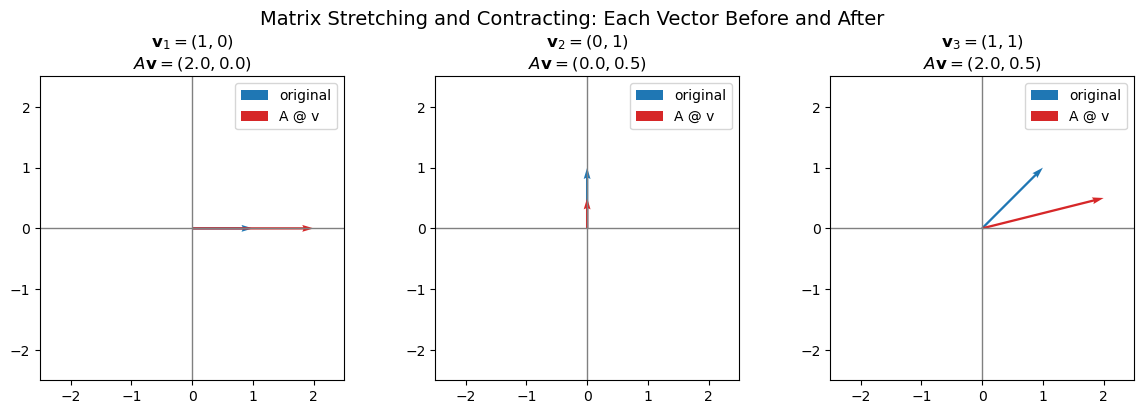

In [61]:
import matplotlib.pyplot as plt
labels = [r"$\mathbf{v}_1 = (1, 0)$", r"$\mathbf{v}_2 = (0, 1)$", r"$\mathbf{v}_3 = (1, 1)$"]

vectors = [v1, v2, v3]

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

for ax, v, label in zip(axes, vectors, labels):
    Av = A @ v

    # Axes setup
    ax.axhline(0, color='gray', lw=1)
    ax.axvline(0, color='gray', lw=1)
    ax.set_aspect('equal', adjustable='box')
    ax.set_xlim(-2.5, 2.5)
    ax.set_ylim(-2.5, 2.5)

    # Plot original vector (thin) and transformed vector (thick)
    ax.quiver(0, 0, *v, angles='xy', scale_units='xy', scale=1, color='C0', alpha=1.0, label='original')
    ax.quiver(0, 0, *Av, angles='xy', scale_units='xy', scale=1, color='C3', lw=2, label='A @ v')

    ax.set_title(label + "\n" + f"$A\\mathbf{{v}} = ({Av[0]:.1f}, {Av[1]:.1f})$")
    ax.legend()

fig.suptitle("Matrix Stretching and Contracting: Each Vector Before and After", fontsize=14)
plt.tight_layout()

# Operations on Matrices

## Operations that directly follow from vector operations

### Matrix Addition and Subtraction

$\color{#EF5645}{\text{Definition}}$: Two $n \times m$ matrices A and B can be added or subtracted to give a new $n \times m$ matrix:
$$(A + B)_{ij} = A_{ij} + B_{ij}.$$

### Scalar-Matrix multiplication

$\color{#EF5645}{\text{Definition}}$: A scalar β and an $n \times m$ matrix a can be multiplied to give a new $n \times m$ matrix: 
$$(βA)_{ij} = \beta A_{ij}.$$

### Elementwise-multiplication (Hadamard Product)

$\color{#EF5645}{\text{Definition}}$: Two $n \times m$ matrices $A$ amd $B$ can be multiplied to give a new $n \times m$ matrix: 
$$(A \odot B)_{ij} = A_{ij}B_{ij}.$$

## Frobenius Norm

$\color{#EF5645}{\text{Definition}}$: For a $n \times m$ matrix $A$, we define the _matrix norm_ as:

<center>
$||A|| = \sqrt{\sum_{i=1}^n \sum_{j=1}^m A_{ij}^2}.$</center>

$\color{#EF5645}{\text{Remark}}$: This definition agrees with the definition of norm of vectors when $n=1$ or $m=1$.

$\color{#047C91}{\text{Exercise}}$: Compute the matrix norm of $A = \begin{vmatrix}
1 & 0 & -1\\
0 & 1 & 1 \end{vmatrix}.$

$\color{#003660}{\text{In Python}}$, we use `np.linalg.norm`.

In [27]:
import numpy as np

A = np.array([
    [1, 0, -1],
    [0, 1, 1]
])
print(np.linalg.norm(A))

2.0


$\color{#047C91}{\text{Exercise}}$: Can you write a function that determines the Frobenius norm of a matrix $A$ in terms of the Eulclidean norm of its column vectors $a_1, \dots, a_m$?

In [136]:
def frobenius_norm(A):
    n, m = np.shape(A)
    norm = 0
    for j in range(m):
        a = A[:,j]
        norm += np.dot(a,a)
    return np.sqrt(norm)


A = np.array([
    [1, 0, -1],
    [0, 1, 1]
])
print(frobenius_norm(A))

2.0


## Transpose

$\color{#EF5645}{\text{Definition}}$: The _transpose of an $n \times m$ matrix_ $A$ is a $m \times n$ matrix, written $A^T$, and is defined by:
$$ (A^T)_{ij} = A_{ji}, \quad i = 1,...,m \quad j=1,...,n$$

$\color{#047C91}{\text{Example}}$: $\begin{vmatrix}
0.2 & 1.2 & 10 \\
0 & -3 & 0
\end{vmatrix}^T = \begin{vmatrix}
0.2 & 0 \\
1.2 & -3 \\
10 & 0
\end{vmatrix}$


$\color{#6D7D33}{\text{Property}}$: The transpose verifies:
- $(A^T)^T = A$
- $(A + B)^T = A^T + B^T$

_Hint:_ $\color{#003660}{\text{In Python}}$, we use `imshow` to plot an image.

[[ 1  0 -1]
 [ 0  1  0]]
[[ 1  0]
 [ 0  1]
 [-1  0]]


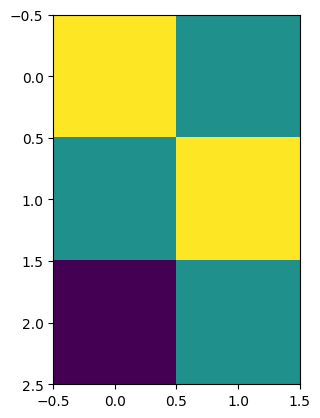

In [6]:
A = np.array([
    [1, 0, -1],
    [0, 1, 0]])

print(A)
print(A.T)
plt.imshow(A)
plt.imshow(A.T)

## Matrix-Matrix Multiplication

$\color{#EF5645}{\text{Definition}}$: An $n \times m$ matrix $A$ and a $m \times k$ matrix $B$ be multiplied to give a new $n \times k$ matrix C: 
$$C = AB$$

where the jth column vector of $C$ is given by the matrix vector product $Ab_j$ where $b_j$ is the jth column vector of $B$.

In [72]:
A = np.array([[1, 2],
              [3, 4],
              [5, 6]])   # shape (3×2)

B = np.array([[2, 0, -1],
              [1, 3, 2]]) # shape (2×3)

# Compute the matrix product
C = A @ B   # shape (3×3)

# Print everything
print("Matrix A (3×2):")
print(A, "\n")

print("Matrix B (2×3):")
print(B, "\n")

print("Matrix C = A @ B (3×3):")
print(C, "\n")

Matrix A (3×2):
[[1 2]
 [3 4]
 [5 6]] 

Matrix B (2×3):
[[ 2  0 -1]
 [ 1  3  2]] 

Matrix C = A @ B (3×3):
[[ 4  6  3]
 [10 12  5]
 [16 18  7]] 



# Recap of Unit 02

- **02: Computing with Data in Python**
  - Vector
      - Vectors: assigning, accessing, visualizing
      - Vector addition, subtraction, scaling
      - Inner product, norm, triangle inequality, distances, angles, Cauchy-Schwarz inequality
  - Matrix
      - Matrices, special matrices
      - **Matrix transpose, addition, subtraction, scaling**
      - **Matrix-vector multiplication, Matrix-matrix multiplication**

# Next week with Louisa!

The course ECE 3 is organized into 4 units.

- Unit 01: Welcome to Python
- Unit 02: Computing with Data in Python
- **Unit 03: Summarizing Data in Python**
- Unit 04: Predicting from Data with Machine Learning in Python